
---

# **Placement Project Logistic Regression**

The main aim of this toy project will be to perform following steps

    1. Preprocess + EDA + Feature Selection
    2. Extract Input and Output Columns
    3. Scale the Values
    4. Train Test Split
    5. Train the Model
    6. Evaluate the Model / Model Selection
    7. Deploy the Model

### **Import Libraries**

In [114]:
import os 
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


### **Load the Dataset**

In [89]:
df = pd.read_csv(r"./data/modified_placement_data.csv")

df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [91]:
# check unique values in 'cgpa'
df['cgpa'].unique()

array(['6,8', '5,9', '5,3', '7,4', '5,8', '7,1', '5,7', '5,0', '6,1', nan,
       '6,0', '6,9', '5,4', '6,4', '5,1', '5,2', '3,3', '4,0', '6,6',
       '4,9', '4,7', '7,0', '7,6', '3,9', '4,8', '8,1', '6,5', '4,6',
       '7,5', '3,5', '8,3', '7,8', '8,0', '7,3', '6,3', '8,5', '6,7',
       '4,4', '4,3', '6,2'], dtype=object)

In [92]:
# convert cgpa "object" column into "float"
df['cgpa'] = df['cgpa'].str.replace(',', '.').astype(float)

# convert 'placement' column to numeric
df['placement'] = df['placement'].map({'Yes': 1, 'No': 0})


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     float64
 1   iq         100 non-null    float64
 2   placement  100 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 2.5 KB


In [93]:
# check missing values
df.isnull().sum()

cgpa         5
iq           0
placement    0
dtype: int64

In [94]:
# impute the missing values
df["cgpa"].fillna(df["cgpa"].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_13936\3930980758.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["cgpa"].fillna(df["cgpa"].median(), inplace=True)


In [95]:
df.isnull().sum()

cgpa         0
iq           0
placement    0
dtype: int64

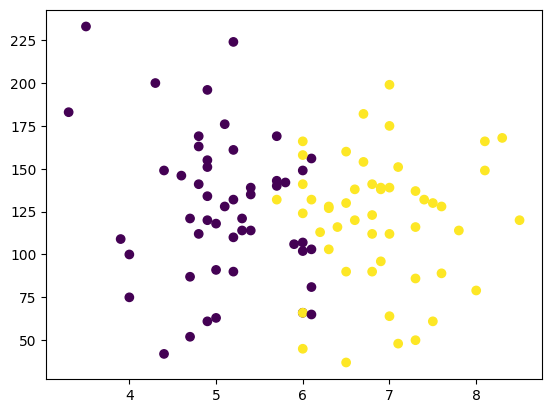

In [96]:
# visualize data
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])
plt.show()

In [97]:
# extract input and output columns
X = df.iloc[:,0:2]
Y = df.iloc[:,-1]

In [98]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [99]:
Y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [100]:
# train test split the data 
train_test_split(X,Y,test_size=0.1)

[    cgpa     iq
 33   6.0  149.0
 74   6.7  154.0
 82   6.5   37.0
 65   8.1  166.0
 16   5.2  224.0
 ..   ...    ...
 78   6.1   81.0
 10   6.0   45.0
 48   6.6  138.0
 94   4.7   52.0
 9    6.0   66.0
 
 [90 rows x 2 columns],
     cgpa     iq
 28   5.2   90.0
 5    7.1   48.0
 20   6.6  120.0
 4    5.8  142.0
 49   5.4  135.0
 29   7.0  112.0
 54   6.0  141.0
 99   6.2  113.0
 66   6.9   96.0
 18   4.0  100.0,
 33    0
 74    1
 82    1
 65    1
 16    0
      ..
 78    0
 10    1
 48    1
 94    0
 9     0
 Name: placement, Length: 90, dtype: int64,
 28    0
 5     1
 20    1
 4     0
 49    0
 29    1
 54    1
 99    1
 66    1
 18    0
 Name: placement, dtype: int64]

In [101]:
# train test split the data 
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)

In [102]:
X_test

,cgpa,iq
51,4.8,141.0
99,6.2,113.0
2,5.3,121.0
61,7.3,137.0
97,6.7,182.0
22,4.9,120.0
88,4.4,149.0
25,5.0,91.0
46,5.3,114.0
14,6.1,103.0


In [103]:
# scale the data
scaler = StandardScaler()

# scale the X_train
X_train = scaler.fit_transform(X_train)

# scale the X_test
X_test = scaler.transform(X_test)

In [104]:
# transformed X_train
X_train

array([[ 1.37882875,  0.11718789],
       [ 0.05960918,  0.21461893],
       [-0.02833879,  1.04278279],
       [-0.02833879, -0.39432508],
       [ 0.67524498, -0.27253628],
       [-0.02833879, -0.51611388],
       [ 0.85114092,  1.84658888],
       [ 0.85114092, -1.44170878],
       [ 0.58729701,  0.75048966],
       [-1.17166242, -0.88148029],
       [-0.55602662, -0.22382075],
       [-0.02833879, -1.39299326],
       [-1.25961039,  0.55562758],
       [ 0.67524498, -0.00460091],
       [-0.73192256,  0.21461893],
       [-0.99576648,  0.67741638],
       [ 0.76319295,  0.3607655 ],
       [ 1.55472469, -0.22382075],
       [-1.87524619, -0.34560956],
       [ 1.20293281,  0.21461893],
       [ 2.17036049, -0.07767419],
       [-1.5234543 ,  1.87094665],
       [-0.99576648,  0.26333445],
       [-0.02833879,  0.01975685],
       [ 1.81856861,  1.04278279],
       [ 1.29088078,  0.16590341],
       [ 0.41140107,  0.89663623],
       [ 0.76319295,  0.38512326],
       [-1.08371445,

In [105]:
# transformed X_train
X_test

array([[-1.08371445,  0.43383878],
       [ 0.14755715, -0.24817851],
       [-0.64397459, -0.05331643],
       [ 1.11498484,  0.33640774],
       [ 0.58729701,  1.43250696],
       [-0.99576648, -0.07767419],
       [-1.43550633,  0.62870086],
       [-0.9078185 , -0.78404925],
       [-0.64397459, -0.22382075],
       [ 0.05960918, -0.49175612]])

In [106]:
# train the model
model = LogisticRegression()

model.fit(X_train,Y_train)

LogisticRegression()

In [107]:
# make prediction with model
y_pred = model.predict(X_test)

In [108]:
accuracy_score(Y_test,y_pred)

0.9

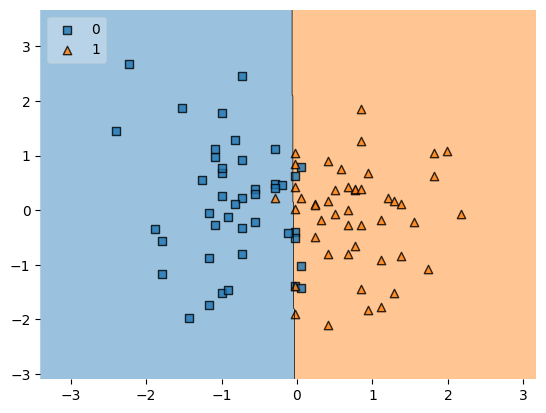

In [ ]:
# plot decision rgions

plot_decision_regions(X_train,Y_train.values,clf=model,legend=2)
plt.show()

In [ ]:
# export the model
pickle.dump(model,open("model.pkl","wb"))

----